Installing latest libraries

In [1]:
import os

In [2]:
!pip install -qq fastai ddgs --use-deprecated=legacy-resolver

In [3]:
from ddgs import DDGS
from fastcore.all import *
import time,json

def search_images(keywords,max_images=100, retries=3):
    for i in range(retries):
        try:
            with DDGS() as ddgs:
                results=ddgs.images(keywords,max_results=max_images)
                if not results:
                    return L()
                return L(results).itemgot('image')
        except Exception as e:
            if i== retries - 1:
                print(f"Error searching for {keywords}:{e}")
                return L()
            time.sleep(2**i)
    return L()
    

In [4]:
urls=search_images('dog photos',max_images=1)
urls[0]

'https://images.pexels.com/photos/19024664/pexels-photo-19024664.jpeg?cs=srgb&dl=pexels-csibeman-19024664.jpg&fm=jpg'

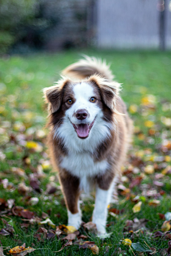

In [5]:
from fastdownload import download_url
dest='dog.jpg'
download_url(urls[0],dest,show_progress=False)
from fastai.vision.all import *
im=Image.open(dest)
im.to_thumb(256,256)

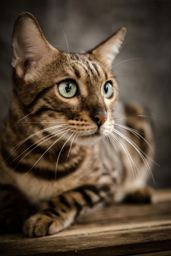

In [6]:
download_url(search_images('cat photos', max_images=1)[0],'cat.jpg',show_progress=False)
Image.open('cat.jpg').to_thumb(256,256)

In [7]:
searches='dog','cat'
path=Path('bird_or_not')
for o in searches:
    dest=(path/o)
    dest.mkdir(exist_ok=True,parents=True)
    download_images(dest,urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o,max_size=400,dest=path/o)

In [8]:
failed=verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

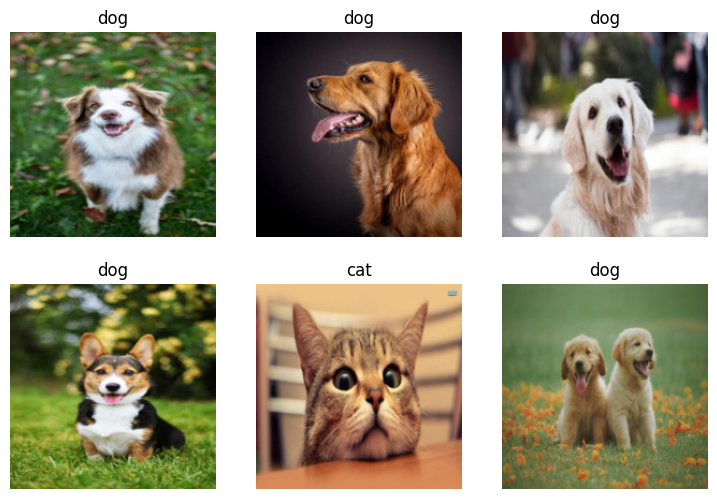

In [9]:
dls=DataBlock(blocks=(ImageBlock,CategoryBlock),get_items=get_image_files,splitter=RandomSplitter(valid_pct=0.2,seed=42),get_y=parent_label,item_tfms=[Resize(192,method='squish')]
             ).dataloaders(path,bs=32)
dls.show_batch(max_n=6)


In [10]:
learn=vision_learner(dls,resnet18,metrics=error_rate)
learn.fine_tune(3)

[W520 21:05:16.161040862 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.206299508 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.209465040 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.210650834 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.212276693 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.214681991 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.220523995 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.222710143 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.223601689 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:05:16.224558199 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:0

epoch,train_loss,valid_loss,error_rate,time
0,0.695329,0.024562,0.016667,00:40


epoch,train_loss,valid_loss,error_rate,time
0,0.080010,0.001097,0.000000,01:00
1,0.050573,0.034748,0.016667,01:08
2,0.031897,0.020647,0.016667,01:22


In [11]:
category,idx,probs=learn.predict(PILImage.create('dog.jpg'))
print(f"This is a: {category}.")
print(f"Probability its a {category}: {probs[idx]:.4f}")
print(f"Probability its a {category}:{ probs}")

[W520 21:09:31.513471713 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:31.536716785 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:31.564874748 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


This is a: dog.
Probability its a dog: 1.0000
Probability its a dog:tensor([1.5398e-07, 1.0000e+00])


In [12]:
learn2=vision_learner(dls,resnet18,metrics=error_rate)
learn2.fine_tune(1)

[W520 21:09:33.971002339 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.008961199 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.039009922 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.040656486 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.069227021 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.094771295 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.096403680 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.097148083 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.098573368 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:09:33.100452277 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:0

epoch,train_loss,valid_loss,error_rate,time
0,0.463422,0.001633,0.000000,00:41


epoch,train_loss,valid_loss,error_rate,time
0,0.037168,0.000703,0.000000,01:09


In [14]:
learn3=vision_learner(dls,resnet34,metrics=error_rate)
learn3.fine_tune(3)

[W520 21:16:20.512194579 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.541376289 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.569155046 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.589370428 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.591090463 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.592441391 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.593903581 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.594964400 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.596112489 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:16:20.597344312 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:1

epoch,train_loss,valid_loss,error_rate,time
0,0.715311,0.026196,0.016667,01:05


epoch,train_loss,valid_loss,error_rate,time
0,0.074723,0.013934,0.016667,01:31
1,0.044009,0.007227,0.000000,01:21
2,0.029973,0.001998,0.000000,01:27


In [19]:
def is_cat(x):return x[0].isupper()
dls2=ImageDataLoaders.from_name_func(
    path,get_image_files(path),valid_pct=0.2,
    label_func=is_cat,item_tfms=Resize(128))
learn4=vision_learner(dls2,resnet34,metrics=error_rate)
learn4.fine_tune(1)

[W520 21:50:37.361408244 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:37.408108102 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:38.453804832 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:38.494819218 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:38.532794275 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:38.543006898 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:38.543656801 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:38.549902669 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:38.566149690 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:50:38.566629479 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 21:5

epoch,train_loss,valid_loss,error_rate,time
0,0.000000,0.000000,0.000000,00:42


epoch,train_loss,valid_loss,error_rate,time
0,0.000000,0.000000,0.000000,01:04


resnet34 has a lower rror rate than resnet18 because of being a deeper model taking more time to computer but can be reduced by reducing image resolution (not by alot) while maintaining the low error rate